# Problem Statement

ACME Insurance Inc. offers affordable health insurance to thousands of customer all over the United States. As the lead data scientist at ACME, you're tasked with creating an automated system to estimate the annual medical expenditure for new customers, using information such as their age, sex, BMI, children, smoking habits and region of residence.

<b>EXERCISE</b>: Before proceeding further, take a moment to think about how can approach this problem. List five or more ideas that come to your mind below:

* Understand the dataset and define input features and target variable (charges)
* Perform data cleaning and preprocessing (handle missing values, encode categories)
* Explore the data using visualization and statistics (EDA)
* Select and train an interpretable model (e.g., linear regression)
* Evaluate the model and explain predictions for new customers

In [1]:
file_path = "./data/medical_data.csv"

In [2]:
import pandas as pd

In [3]:
medical_df = pd.read_csv(file_path)

In [4]:
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


The dataset contains 1338 rows and 7 columns. Each row of the dataset contains information about one customer

Our object is to find a way to estimate the value in the "charges" column using the valuese in the other columns. If we can do so for the historical data, then we should be able to estimate charages for new customers too, simply by asking for information like their age, sex, BMI, no. of children, smoking habits and region.

let's check the data type for each column.

In [5]:
medical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


The ranges of values in the numerical columns seem reasonable too. So we may not have to do much data cleaning or correction. The "charges" column seems to be significantly skewed however, as the median (50 perrcentile) is much lower that the maximum value.

# Exploratory Analysis and Visualization

Let's explore the data by visualizing the distribution of values in some columns of the dataset, and the relationships between "charges" and other columns.

In [7]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

The following settings will improve the default style and font sizes for our charts

In [8]:
sns.set_style('darkgrid')

In [9]:
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

## Age

Age is a numeric column. The minimum age in the dataset is 18 and the aximum age is 64. Thus, we can visualize the distribution of age using a histogram with 47 bins (one for each year) and a box plot. We'll use plotly to make the chart interactive, but you can create similar charts using Seaborn.

In [10]:
 medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

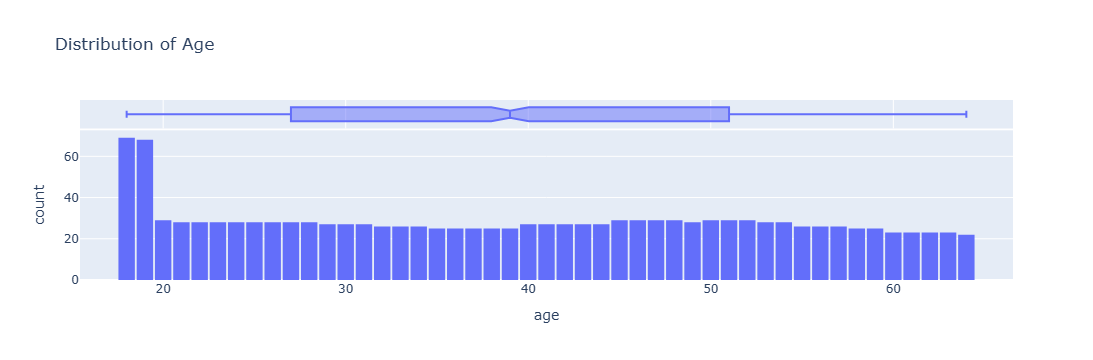

In [11]:
fig = px.histogram(medical_df,
                   x='age',
                   marginal='box',
                   nbins=47,
                   title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

The distribution of ages in the datset is almost uniform, with 20-30 custormers at every age, except for the ages 18 and 19, which seem to have over twice as many customers as other ages. The uniform distribution might arise from the fact that there isn't a big variation in the number of people of any given age(between 18 & 64) in the USA.

## Body Mass Index (BMI)

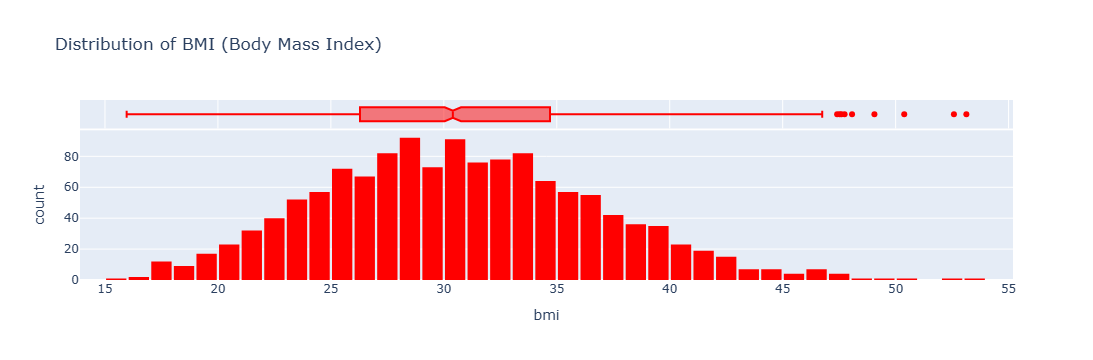

In [12]:
fig = px.histogram(medical_df,
                   x='bmi',
                   marginal='box',
                   color_discrete_sequence=['red'],
                   title='Distribution of BMI (Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()

## Charges

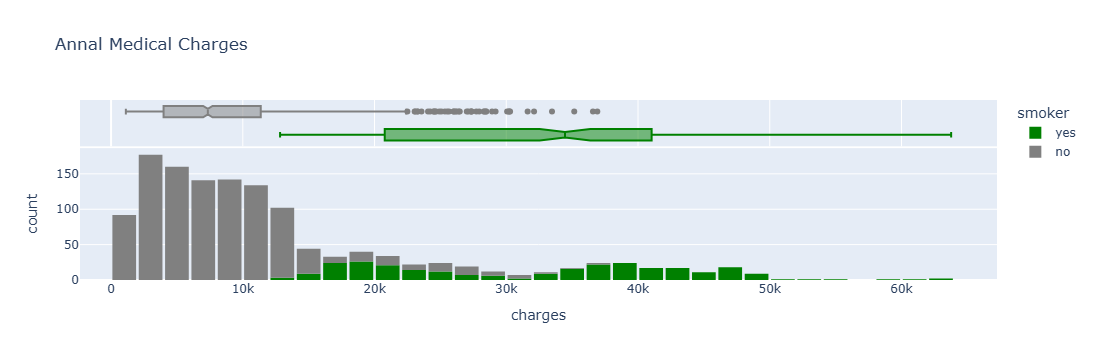

In [13]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='smoker',
                   color_discrete_sequence=['green', 'grey'],
                   title='Annal Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

* For most customers, the annual medical charges are under $10,000. Only a small fraction of customer have higher medical expenses, possibly due to accidents, major illnesses and genetic diseases. The distribution follow a "power law"

* There is a significant difference in medical expenses between smokers and non-smokers. While the median for non-smokers is `$7300`, the emedian for smokers is close to `$35,000`

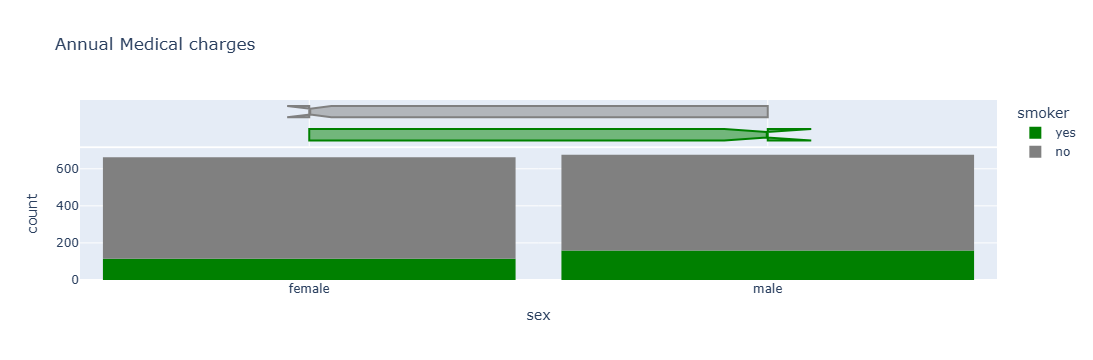

In [14]:
fig = px.histogram(medical_df,
                   x='sex',
                   marginal='box',
                   color='smoker',
                   color_discrete_sequence=['green', 'grey'],
                   title='Annual Medical charges')
fig.update_layout(bargap=0.1)
fig.show()

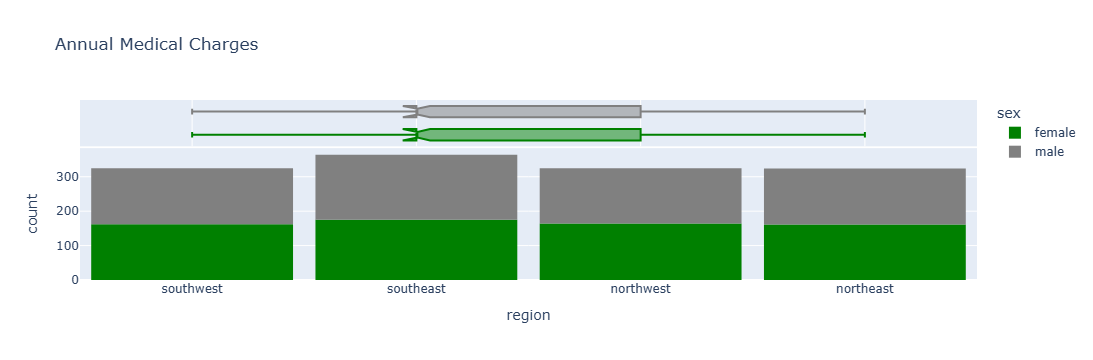

In [15]:
fig = px.histogram(medical_df,
                   x='region',
                   marginal='box',
                   color='sex',
                   color_discrete_sequence = ['green', 'grey'],
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

In [16]:
 medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

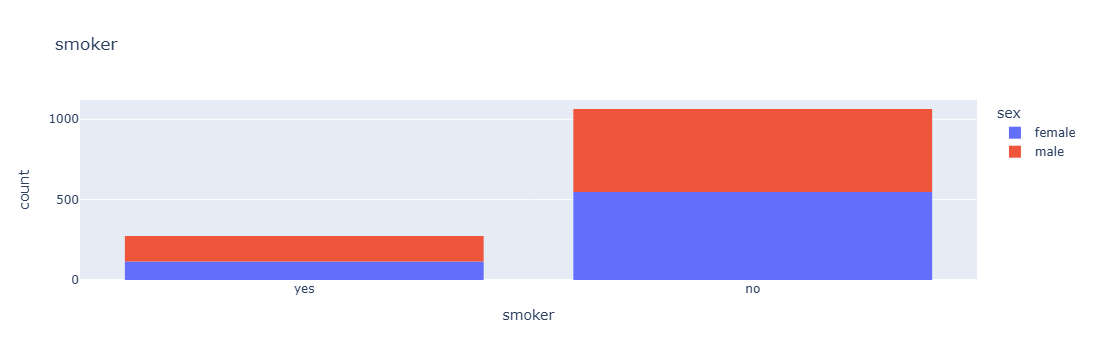

In [17]:
 px.histogram(medical_df, x='smoker', color='sex', title='smoker')

It apears that 20% of customers have reported that they smoke. Can you verify whether this matches the national average, assuming the data was collected in 2010? we can also see that smoking appears a more common habit among males. Can you verify this?

## Age and Charges

Let's visualize the relationship between "age" and "charges" using a scatter plot. Each point in the scatter plot represents one customer. We'll also use values in the "smoker" column to color the points.

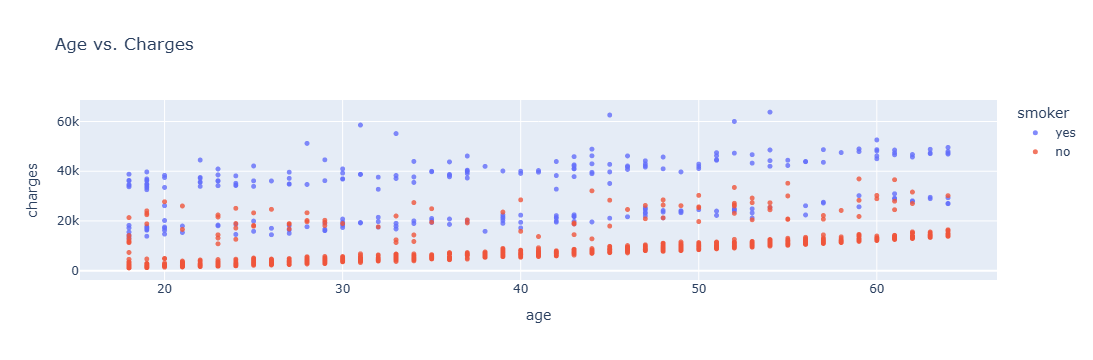

In [18]:
fig = px.scatter(medical_df,
                  x = 'age',
                  y='charges',
                  color='smoker',
                  opacity=0.8,
                  hover_data=['sex'],
                  title='Age vs. Charges')
fig.update_traces(marker_size = 5)
fig.show()

We can make the following observations from the above chart:

* The general trend seems to be that medical charges increse with age, as we might expect. However, there is significant variation at every age, and it's clear that age alone cannot be used to accurately determine medical charges.

* We can see three "clusters" of points, each of which seems to form a line with an increasing slop

1. The first and the largest cluster consists primary of presumably "healthy non-smokers" who have relatively low medical charges compared to others.

2. The second cluster contains a mix of smokers and non-smokers with medial issues and smokers without major medical issues

3. The final cluster consists exclusively of smokers, presumably smokers with major medical issues that are possibly related to or worsened by smoking

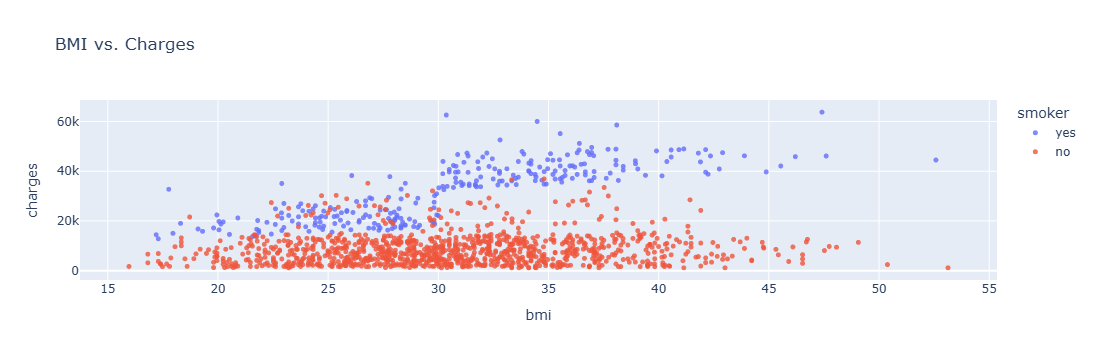

In [19]:
fig = px.scatter(medical_df,
                  x = 'bmi',
                  y='charges',
                  color='smoker',
                  opacity=0.8,
                  hover_data=['sex'],
                  title='BMI vs. Charges')
fig.update_traces(marker_size = 5)
fig.show()

* There is a positive correlation between BMI and charges — as BMI increases, medical expenses tend to increase

It appears that for non-smokers, an increase in BMI doesn't seem to be related to an increase in medical charges. However, medical charges seem to be significantly higher for smokers with a BMI greater than 30.

## Charges vs children

### Violin plot

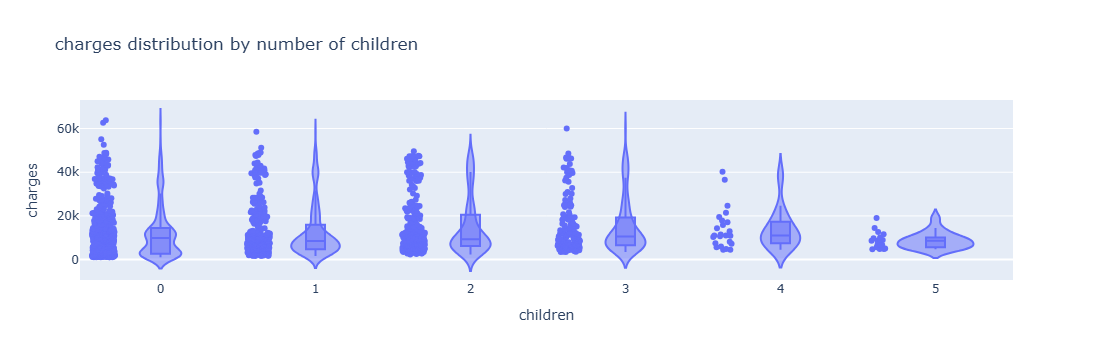

In [20]:
fig = px.violin(medical_df,
                x ='children',
                y ='charges',
                box=True,
                points='all',
                title='charges distribution by number of children')
fig.show()

### Bar Plot

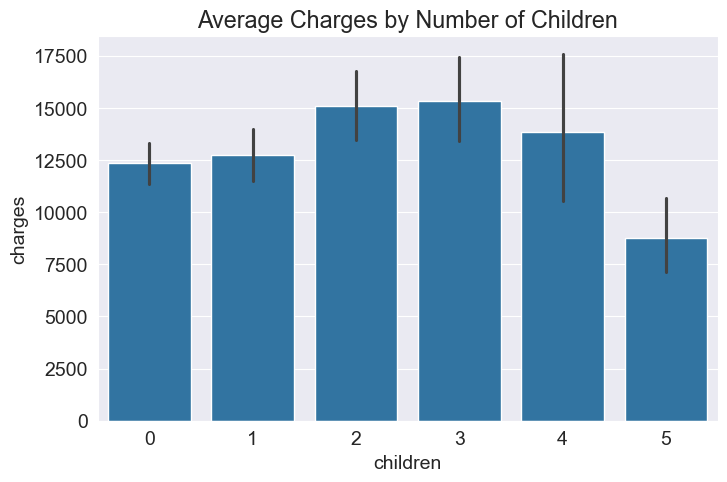

In [21]:
plt.figure(figsize=(8,5))
sns.barplot(x='children', y='charges', data=medical_df)
plt.title('Average Charges by Number of Children')
plt.show()

## Correlation

As you can tell from the analysis, the values in some columns are more closely related to the values in "charges" compared to other columns. E.g., "age" and "charges" seem to grow together, whereas "bmi" and "charges" don't.

This relationship is often expressed numerically using a measure called the correlation coefficient, which can be computed  using the .corr metho of Pandas series

In [22]:
medical_df.charges.corr(medical_df.age)

np.float64(0.2990081933306476)

In [23]:
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362884)

To compute the correlation for categorical columns, they must first be converted into numeric columns.

In [24]:
smoker_values = {'no': 0, 'yes': 1}
smoker_numeric = medical_df.smoker.map(smoker_values)
medical_df.charges.corr(smoker_numeric)

np.float64(0.7872514304984767)

Here's how correlation coefficients can be interpreted
* <b>Strength:</b> The greater the absolute value of the correlation coefficient, the stronger the relationship.

* The extreame values of -1 and 1 indicate a perfectly linear relationship where a change in one variable is accompanied by a perfectly consistent change in the other. For these relationships, all of the data points fall on a line. In practice, you won't see either type of perfect relationship

* A coefficient of zero represents no linear relationship. As one variable increases, there is no tendency in the other variable to either increase or decrease.

* When the value is in-between -1 or 1, the streangth of the relationship increases and the data points tend to fall closer to a line

* <b>Direction:</b> The sign of the coefficient represents the direction of the relationship.

* Positive coefficients indicate that when the value of one variable increases, the value of the other variable also tends increase. Positive relationships produce an upward slope on a scatterplot

* Negative coefficients represent cases when the value of one variable increases, the value of the other variable tends to decrease. Negative relationships produce a downward slop

Alternative Formula (Using Means)

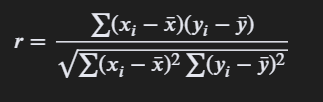

Graphs

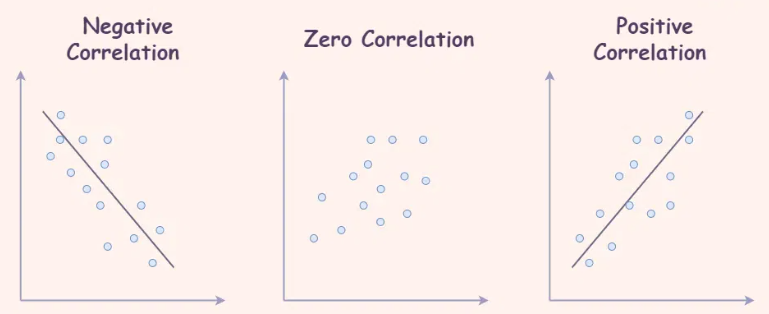

In [25]:
sex_values = {'female': 0, 'male': 1}
sex_numeric = medical_df.sex.map(sex_values)
medical_df.charges.corr(sex_numeric)

np.float64(0.057292062202025366)

In [26]:
medical_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


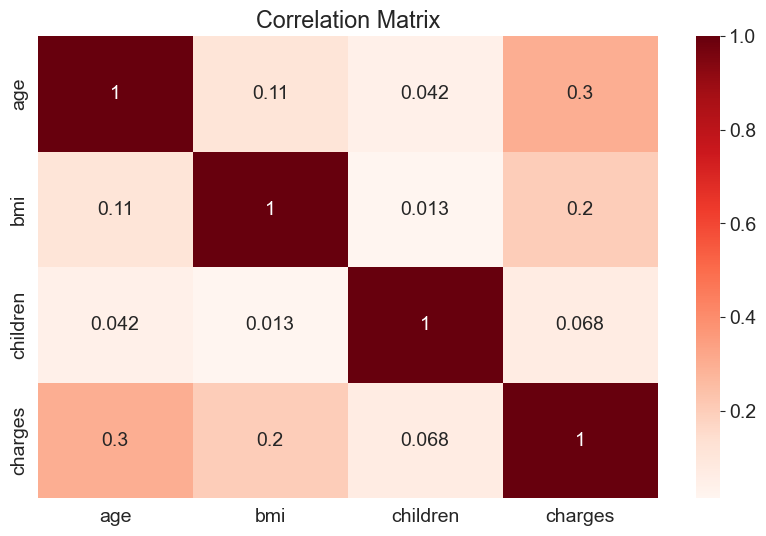

In [27]:
sns.heatmap(medical_df.corr(numeric_only=True),
            cmap='Reds',
            annot=True)
plt.title('Correlation Matrix');

## Linear Regression using a Single Feature

We now know that the "smoker" and "age" columns have the strongest correlation with "charges". Let's try to find a way of estimating the value of "charges" using the value of "age" for non smokers. First, let's create a data frame containing just the data for non-smokers.

In [28]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

Let's now visualize the relationship between "age" and "charges"

<Axes: title={'center': 'Age vs. Charges'}, xlabel='age', ylabel='charges'>

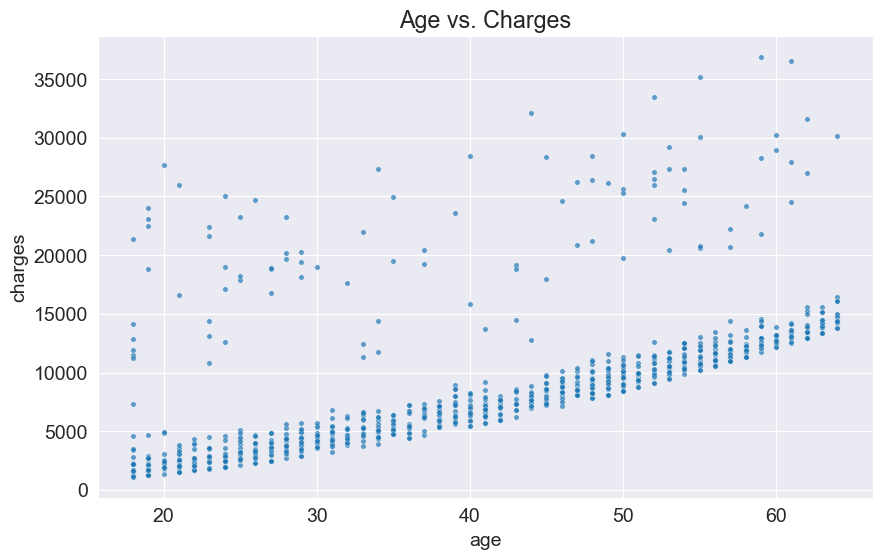

In [29]:
plt.title('Age vs. Charges')
sns.scatterplot(data=non_smoker_df, x='age', y = 'charges', alpha=0.7, s = 15)

Apart from a few exceptions, the points seem to form a line. We'll try and 'fit' a line using this points, and use the line to predict charges for a given age. A line on the X & Y coordinates has the following formula:

y = wx + b

The line is characterized two numbers: w(called "slope") and b (called "intercept")

### Model

In the abovve case, the x acis shows "age" and the y axis shows "charges". Thus we're assume the following relationship between the two:

charges = w x age + b

We'll try determine w and b for the line that best fits the data.

* This technique is called linear regression, and we call the above equation a linear regression model, because it models the relationship between "age" ange "charges" as a straight line.

* The numbers w and b are called the parameters or weights of the model

* The values in the "age" column of the dataset are called the inputs to the model and the values in the charges column are called "targets"

Let's define a helper function `estimate_charges`, to compute charges given age, w and b

In [30]:
def estimate_charges(age, w, b):
    return w * age + b

The `estimate_charges` function is our very first model

Let's guess the values for w and b and use them to estimate the value for charges

In [31]:
w = 50
b = 100

In [32]:
ages = non_smoker_df.age
estimated_charges = estimate_charges(ages, w, b)

We can plot the estimated charges using a line graph

Text(0, 0.5, 'Estimated Charges')

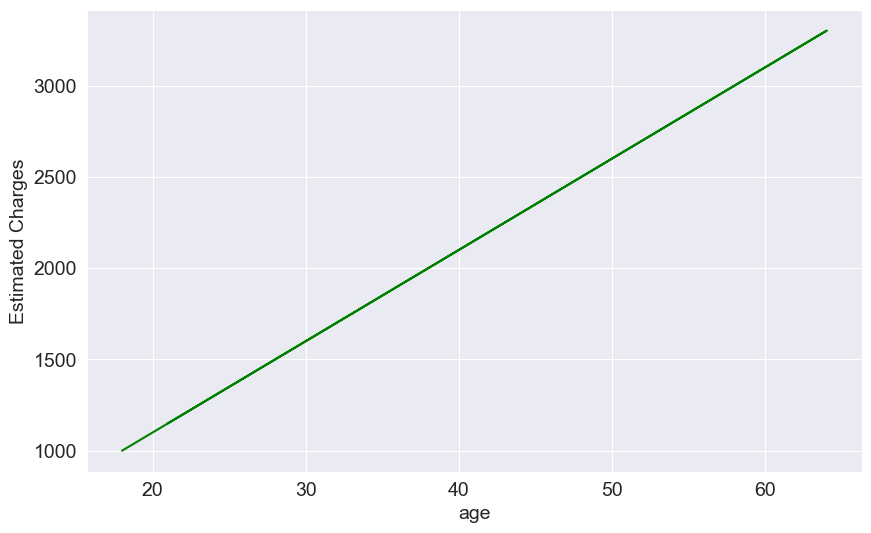

In [36]:
plt.plot(ages, estimated_charges, color='green');
# plt.plot(ages, estimated_charges, color='red', linestyle='-', marker='o')
plt.xlabel('age');
plt.ylabel('Estimated Charges')

As expected, the points lie on straight line.

We can overlay this line on the actual data, so see how well our model fits the data

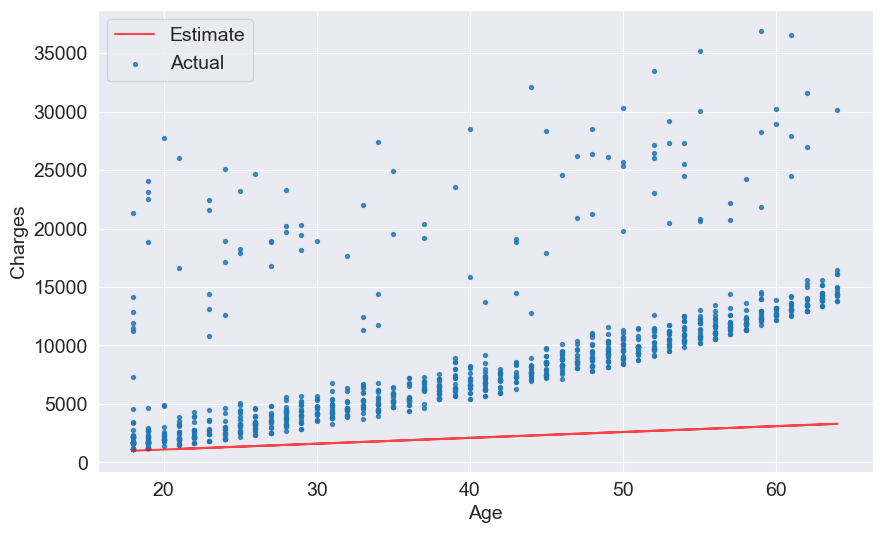

In [40]:
target = non_smoker_df.charges

plt.plot(ages, estimated_charges, 'r', alpha = 0.7);

plt.scatter(ages, target, s=8, alpha=0.8)
plt.xlabel('Age');
plt.ylabel('Charges')
plt.legend(['Estimate', 'Actual']);

Clearly, the our estimatees are quite poor and the line does not "fit" the data. Howver we can try different values of w and b to move the line around. Let's defind a helper function `try_parameters` which takes w and b as inputs and creates the above plot

In [42]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.9)
    plt.scatter(ages, target, s=8, alpha=0.8)
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual'])

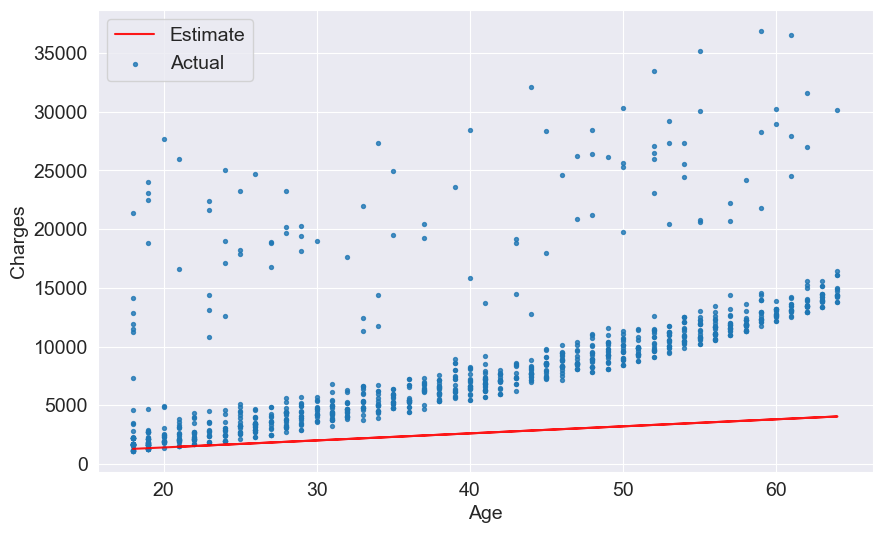

In [43]:
try_parameters(60, 200)

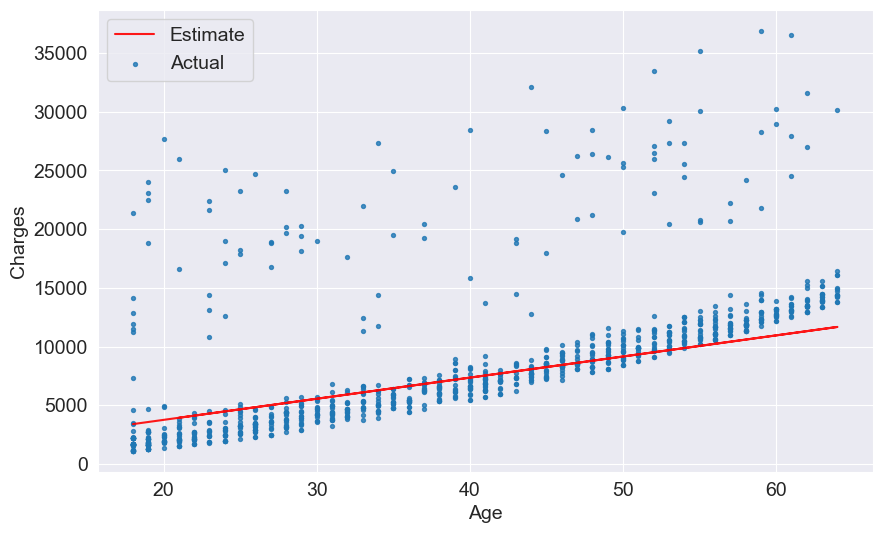

In [49]:
try_parameters(180, 150)

### Loss/Cost Function

We can compate our model's prediction with the actual targets using the following method:

* Calculate the difference between the targets and predictions (the differenced is called the "residual")

* Square all elements of the difference matrix to remove negative values

* Calculate the average of the elements in the resulting matrix

* Take the square root of the result

The result is a single number, know as the root mean squared error (RMSE). The above description can be stated mathematically as follows

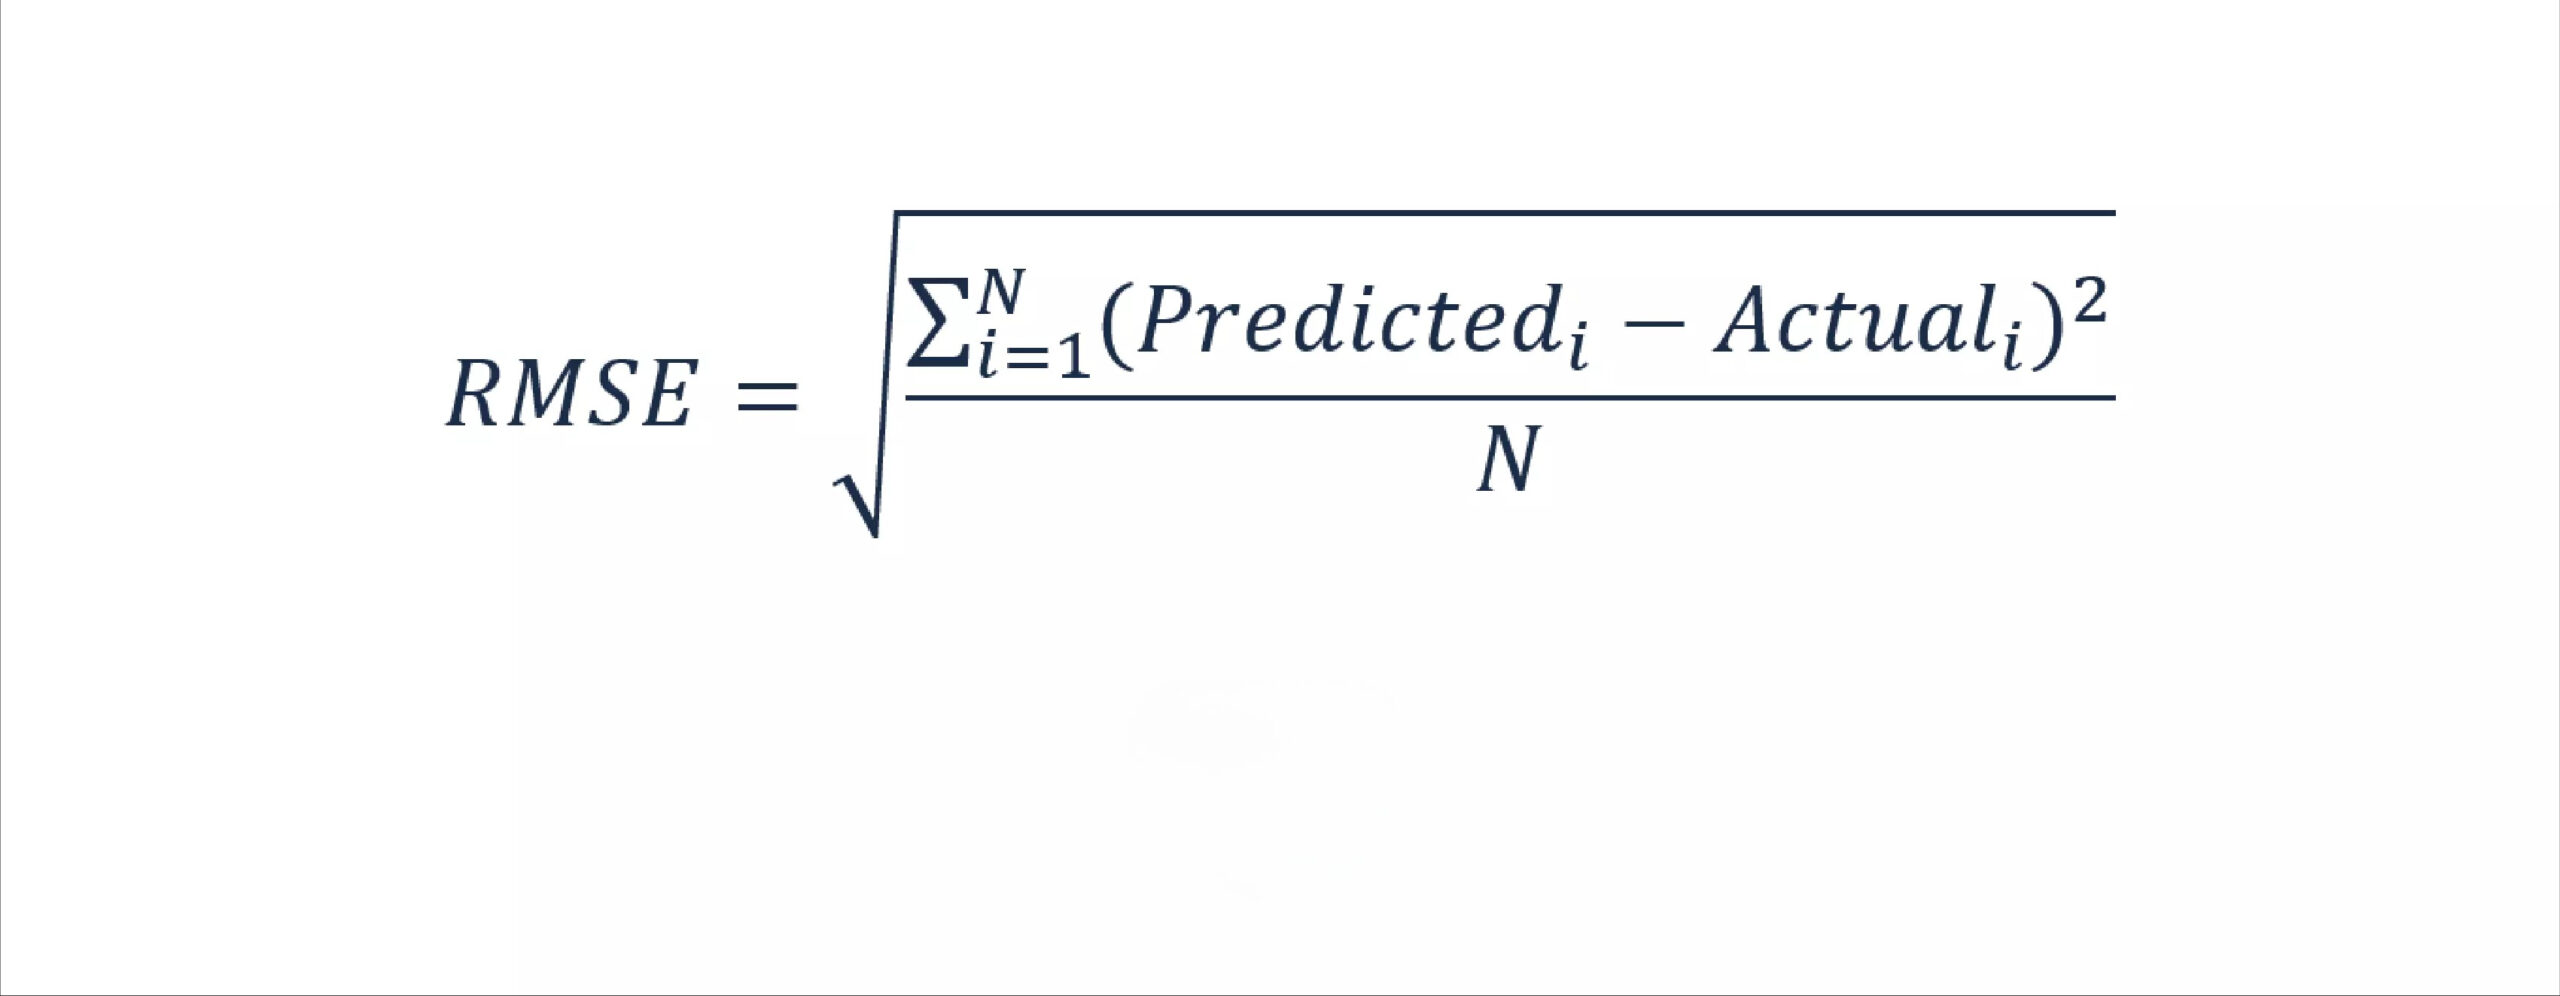

Let's define a function to compte the RMSE

In [50]:
import numpy as np

In [51]:
def rmse(target, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

Let's compute the RMSE for our model with a sample set oof weights 

In [52]:
w = 50
b = 100

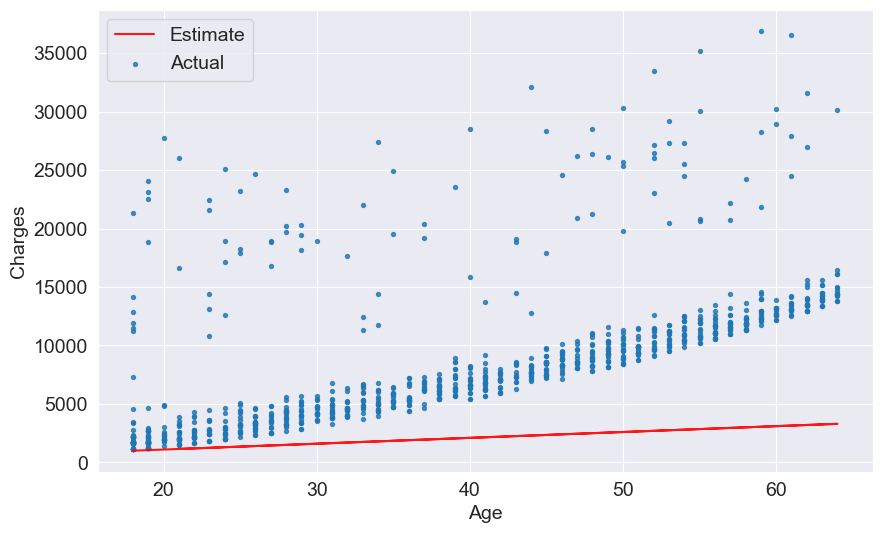

In [54]:
try_parameters(w, b)

In [56]:
targets = non_smoker_df['charges']
predicted = estimate_charges(non_smoker_df.age, w, b)

In [57]:
rmse(targets, predicted)

np.float64(8461.949562575493)

Here's how we can interpreet the above number. On average, each element in the predication differs from the actual target by $8461.

The result is called the loss because it indicates how bad the model is at predicting the target variables. It represents information loss in the model: the lower the loss, the better the model

Let's modify the try_parameters functions to also display the loss.

In [58]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    predictions = estimate_charges(ages, w, b)

    plt.plot(ages, predictions, 'r', alpha=0.9)
    plt.scatter(ages, target, s=8, alpha=0.8)
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Prediction', 'Actual'])

    loss = rmse(target, predictions)
    print("RMSE Loss: ", loss)

RMSE Loss:  8461.949562575493


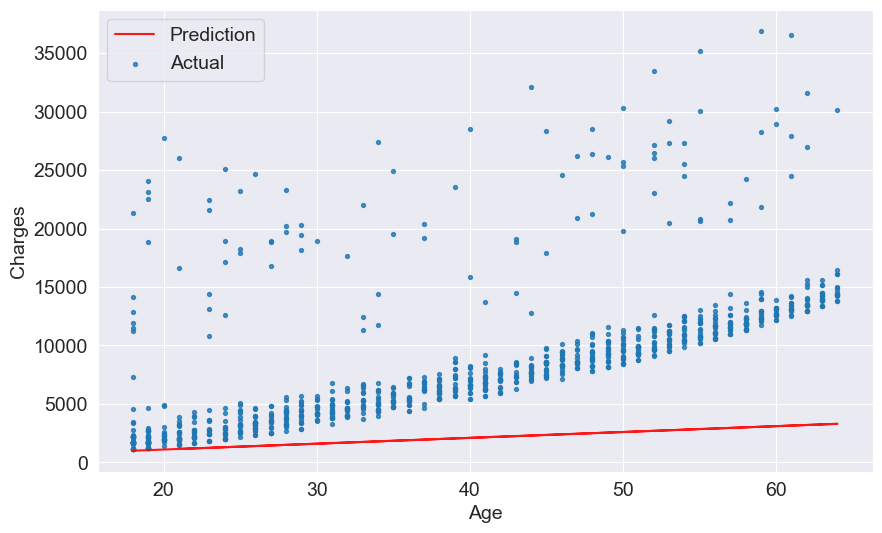

In [60]:
try_parameters(50, 100)

RMSE Loss:  6826.734303208685


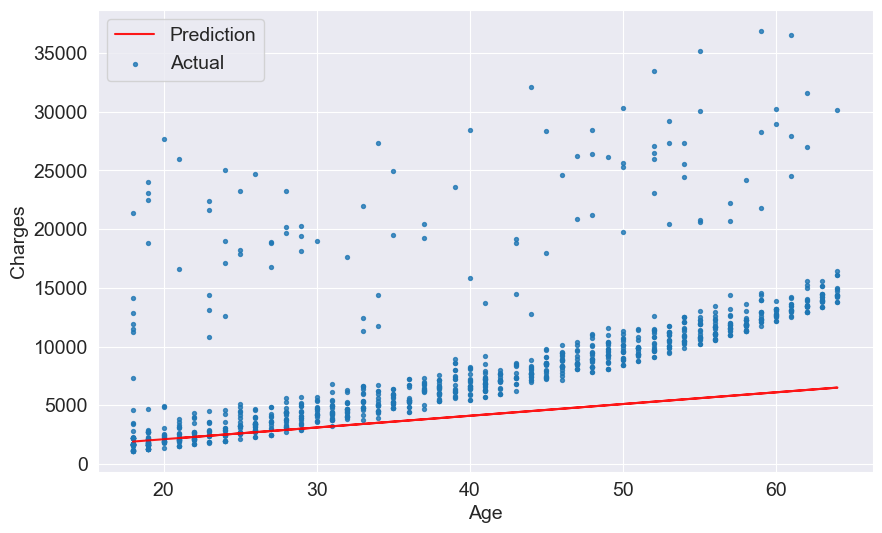

In [61]:
try_parameters(100, 100)

RMSE Loss:  5531.361799730388


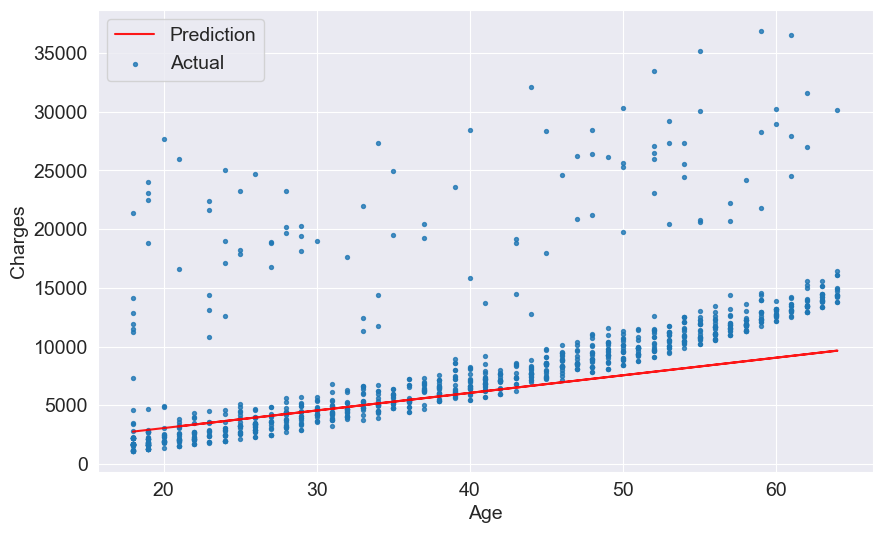

In [62]:
try_parameters(150, 50)

RMSE Loss:  4793.904061890193


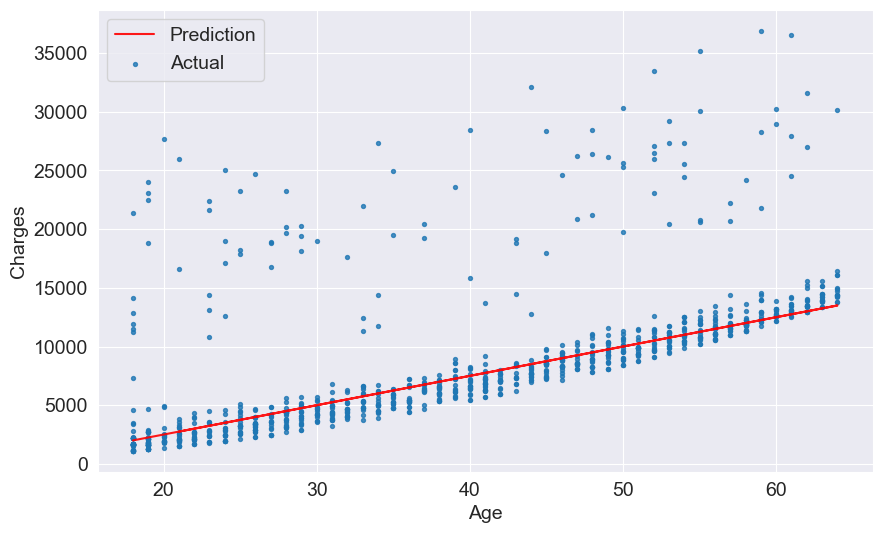

In [74]:
try_parameters(250, -2500)

### Optimizer

Next, we need a strategy to modify weights `w` and `b` to reduce the loss and improve the "fit" of the line to the data

* Ordinary Least Squares (better for smmaler datasets)
* Stochastic Gradient descent (better for larger datasets)

Both of these have the same objective: to minimize the loss, however while ordinary least squares directly computes the best values of w and b and slowly improving them using derivatives.